# Laboratorio 7 — Spark MLlib: Segmentación y Predicción del Salario (ENEIC)

**Curso:** CC3084 · Ciencia de Datos · UVG
**Integrantes del equipo:** _completar nombres y carnés_

Este cuaderno responde la sección **Análisis Exploratorio Avanzado y
Segmentación (25 pts)** del laboratorio, usando las bases de Personas de la
ENEIC (INE Guatemala) 2025 (entrenamiento/desarrollo) y el primer trimestre
de 2026 (prueba final, reservado). Todo el procesamiento y el aprendizaje
automático se hacen con **PySpark / MLlib** (no se usa scikit-learn para
entrenar modelos). El notebook está pensado para ejecutarse de principio a
fin sin depender de variables creadas en corridas anteriores.

Ver el enunciado completo en
[`laboratorio7-spark-mllib-2026.md`](../laboratorio7-spark-mllib-2026.md) y
las variables derivadas en [`codebook.md`](../codebook.md).

## 0. Preparación del entorno

Spark no tiene lector nativo de Excel: cada archivo `.xlsx` se lee con
`pandas`/`openpyxl`, se seleccionan solo las columnas necesarias (para
controlar memoria), se homologan los tipos y se convierte a Spark. A partir
de ahí, toda la preparación analítica y el modelado se hacen en Spark.

In [1]:
import os
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql import types as T

spark = (
    SparkSession.builder
    .appName("Lab7SparkMLlib")
    .master("local[*]")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print("Spark:", spark.version)
print("Java:", spark.sparkContext._jvm.java.lang.System.getProperty("java.version"))

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/24 23:54:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1
Java: 17.0.20.1


In [2]:
DIR_RAW = Path("../data/raw")
DIR_PROCESSED = Path("../data/processed")
DIR_PROCESSED.mkdir(parents=True, exist_ok=True)

# Muestreo seguro para graficar: nunca se usa para metricas.
N_MUESTRA_GRAFICOS = 8000
SEMILLA = 42

plt.rcParams["figure.dpi"] = 110

## 1. Carga, armonización y calidad de datos (5 pts)

### Identificación del período

Cada archivo se identifica por su **procedencia** (nombre de archivo), no
por el valor crudo de `TRIMESTRE` (que no corresponde al trimestre
calendario — ver tabla del enunciado). `periodo_archivo`, `anio_archivo` y
`trimestre_calendario` se asignan por archivo de origen; `TRIMESTRE` se
conserva sin modificar, solo para auditoría.

In [3]:
# Metadatos de periodo por archivo de origen (NO se derivan de TRIMESTRE).
METADATOS_ARCHIVO = {
    "Personas_ENEIC_2025T1.xlsx": dict(periodo_archivo="2025T1", anio_archivo=2025, trimestre_calendario=1),
    "Personas_ENEIC_2025T2.xlsx": dict(periodo_archivo="2025T2", anio_archivo=2025, trimestre_calendario=2),
    "Personas_ENEIC_2025T3.xlsx": dict(periodo_archivo="2025T3", anio_archivo=2025, trimestre_calendario=3),
    "Personas_ENEIC_2025T4.xlsx": dict(periodo_archivo="2025T4", anio_archivo=2025, trimestre_calendario=4),
    "Personas_ENEIC_2026T1.xlsx": dict(periodo_archivo="2026T1", anio_archivo=2026, trimestre_calendario=1),
}

# Columnas originales requeridas (ver codebook.md).
COLUMNAS_CRUDAS = [
    "ANIO", "TRIMESTRE", "DOMINIO", "NUM_HOGAR", "FACTOR", "NUM_PERSONA",
    "P02A03", "P05C07A", "P05C07B", "P05H01A", "P03A03A", "P05C16",
    "OCUPADOS", "P05D01",
]

RENOMBRES = {
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "OCUPADOS": "ocupado",
    "P05D01": "salario_mensual",
}

COLUMNAS_CODIGO = ["DOMINIO", "NUM_HOGAR", "NUM_PERSONA", "nivel_educativo", "categoria_ocupacional"]
COLUMNAS_NUMERICAS = [
    "ANIO", "TRIMESTRE", "FACTOR", "edad", "antiguedad_anios",
    "antiguedad_meses", "horas_semanales", "ocupado", "salario_mensual",
]

In [4]:
def _codigo_a_texto(valor):
    # Normaliza un codigo que puede llegar como numero o como texto
    # (ej. 1, 1.0, '1', ' 1 ') a una unica representacion de texto.
    if pd.isna(valor):
        return None
    if isinstance(valor, str):
        valor = valor.strip()
        if valor == "":
            return None
    try:
        numero = float(valor)
        if numero.is_integer():
            return str(int(numero))
        return str(numero)
    except (TypeError, ValueError):
        return str(valor).strip()


def cargar_trimestre(nombre_archivo: str) -> pd.DataFrame:
    # Lee un archivo crudo de Personas, selecciona las columnas requeridas
    # y homologa sus tipos. Procesa un archivo a la vez para controlar memoria.
    ruta = DIR_RAW / nombre_archivo
    crudo = pd.read_excel(ruta, sheet_name=0, dtype=object, engine="openpyxl")
    faltantes = [c for c in COLUMNAS_CRUDAS if c not in crudo.columns]
    if faltantes:
        raise ValueError(f"{nombre_archivo}: faltan columnas {faltantes}")

    df = crudo[COLUMNAS_CRUDAS].rename(columns=RENOMBRES).copy()

    for col in COLUMNAS_CODIGO:
        df[col] = df[col].map(_codigo_a_texto)
    for col in COLUMNAS_NUMERICAS:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    meta = METADATOS_ARCHIVO[nombre_archivo]
    df["archivo_origen"] = nombre_archivo
    df["periodo_archivo"] = meta["periodo_archivo"]
    df["anio_archivo"] = meta["anio_archivo"]
    df["trimestre_calendario"] = meta["trimestre_calendario"]
    return df

### Unión de los cuatro trimestres de 2025 con `unionByName`

`IV de 2025` no puede apilarse por **posición** de columnas con los otros
tres archivos porque trae 302 columnas en lugar de 270 (preguntas
adicionales del trimestre): la misma variable (p. ej. `P05D01`) no está en
la misma posición ordinal en ese archivo. `unionByName` une por **nombre**
de columna, no por posición, así que es la única forma correcta de apilar
archivos con distinto número/orden de columnas.

In [5]:
ESQUEMA = T.StructType([
    T.StructField("archivo_origen", T.StringType(), False),
    T.StructField("periodo_archivo", T.StringType(), False),
    T.StructField("anio_archivo", T.IntegerType(), False),
    T.StructField("trimestre_calendario", T.IntegerType(), False),
    T.StructField("ANIO", T.DoubleType(), True),
    T.StructField("TRIMESTRE", T.DoubleType(), True),
    T.StructField("DOMINIO", T.StringType(), True),
    T.StructField("NUM_HOGAR", T.StringType(), True),
    T.StructField("NUM_PERSONA", T.StringType(), True),
    T.StructField("FACTOR", T.DoubleType(), True),
    T.StructField("edad", T.DoubleType(), True),
    T.StructField("antiguedad_anios", T.DoubleType(), True),
    T.StructField("antiguedad_meses", T.DoubleType(), True),
    T.StructField("horas_semanales", T.DoubleType(), True),
    T.StructField("nivel_educativo", T.StringType(), True),
    T.StructField("categoria_ocupacional", T.StringType(), True),
    T.StructField("ocupado", T.DoubleType(), True),
    T.StructField("salario_mensual", T.DoubleType(), True),
])

COLUMNAS_ORDENADAS = [f.name for f in ESQUEMA.fields]

_COLUMNAS_INT = {"anio_archivo", "trimestre_calendario"}
_COLUMNAS_DOUBLE = {
    "ANIO", "TRIMESTRE", "FACTOR", "edad", "antiguedad_anios",
    "antiguedad_meses", "horas_semanales", "ocupado", "salario_mensual",
}


def a_spark(pdf: pd.DataFrame) -> DataFrame:
    # Convierte cada columna a un tipo Python nativo exacto (float/int/str),
    # con None real para los faltantes. OJO: si el resultado se vuelve a
    # asignar a una columna de un DataFrame de pandas con dtype float64,
    # pandas fuerza None -> NaN de nuevo (pierde la nulidad). Por eso se
    # arma cada columna como lista de Python pura (via .tolist()) y se
    # combinan al final, sin pasar nunca por una Series float64.
    columnas_valores = {}
    for columna in COLUMNAS_ORDENADAS:
        crudo = pdf[columna].tolist()
        if columna in _COLUMNAS_INT:
            columnas_valores[columna] = [int(v) if pd.notnull(v) else None for v in crudo]
        elif columna in _COLUMNAS_DOUBLE:
            columnas_valores[columna] = [float(v) if pd.notnull(v) else None for v in crudo]
        else:
            columnas_valores[columna] = [str(v) if pd.notnull(v) else None for v in crudo]
    filas = list(zip(*[columnas_valores[c] for c in COLUMNAS_ORDENADAS]))
    return spark.createDataFrame(filas, schema=ESQUEMA)


ARCHIVOS_2025 = [
    "Personas_ENEIC_2025T1.xlsx",
    "Personas_ENEIC_2025T2.xlsx",
    "Personas_ENEIC_2025T3.xlsx",
    "Personas_ENEIC_2025T4.xlsx",
]

dfs_2025 = [a_spark(cargar_trimestre(nombre)) for nombre in ARCHIVOS_2025]
personas_2025 = reduce(DataFrame.unionByName, dfs_2025).cache()

print("Registros unidos 2025 (antes de filtros):", personas_2025.count())

Registros unidos 2025 (antes de filtros): 203676


In [6]:
personas_2025.printSchema()
personas_2025.select(
    "archivo_origen", "periodo_archivo", "edad", "antiguedad_anios",
    "antiguedad_meses", "horas_semanales", "nivel_educativo",
    "categoria_ocupacional", "salario_mensual",
).show(5, truncate=False)

root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- ocupado: double (nullable = true)
 |-- salario_mensual: double (nullable = true)



+--------------------------+---------------+----+----------------+----------------+---------------+---------------+---------------------+---------------+
|archivo_origen            |periodo_archivo|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo|categoria_ocupacional|salario_mensual|
+--------------------------+---------------+----+----------------+----------------+---------------+---------------+---------------------+---------------+
|Personas_ENEIC_2025T1.xlsx|2025T1         |14.0|NULL            |NULL            |NULL           |3              |NULL                 |NULL           |
|Personas_ENEIC_2025T1.xlsx|2025T1         |42.0|23.0            |0.0             |35.0           |5              |6                    |NULL           |
|Personas_ENEIC_2025T1.xlsx|2025T1         |42.0|20.0            |0.0             |1.0            |5              |1                    |7000.0         |
|Personas_ENEIC_2025T1.xlsx|2025T1         |9.0 |NULL            |NULL      

### Registros por archivo antes de los filtros

In [7]:
personas_2025.groupBy("periodo_archivo").count().orderBy("periodo_archivo").show()

+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|51588|
|         2025T2|51167|
|         2025T3|51583|
|         2025T4|49338|
+---------------+-----+



### Faltantes por variable seleccionada, antes de aplicar filtros

In [8]:
total_2025 = personas_2025.count()

columnas_analiticas = [
    "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
    "nivel_educativo", "categoria_ocupacional", "ocupado", "salario_mensual",
    "DOMINIO",
]

faltantes = personas_2025.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in columnas_analiticas
]).toPandas().T.rename(columns={0: "faltantes"})
faltantes["porcentaje"] = (faltantes["faltantes"] / total_2025 * 100).round(2)
faltantes

,faltantes,porcentaje
edad,0,0.00
antiguedad_anios,115454,56.69
antiguedad_meses,115454,56.69
horas_semanales,115454,56.69
nivel_educativo,26344,12.93
categoria_ocupacional,115454,56.69
ocupado,115454,56.69
salario_mensual,150651,73.97
DOMINIO,0,0.00


### Filtros de población y calidad

Se aplican en un **orden fijo** (documentado abajo) para poder reportar,
paso a paso, cuántos registros se excluyen en cada criterio.

In [9]:
def aplicar_filtros(df: DataFrame, columnas_auditoria=("archivo_origen", "periodo_archivo")):
    pasos = [
        ("edad valida (finita, >= 15)", F.col("edad").isNotNull() & (F.col("edad") >= 15)),
        ("ocupado == 1", F.col("ocupado") == 1),
        ("asalariado (categoria_ocupacional en 1,2,3,4)", F.col("categoria_ocupacional").isin("1", "2", "3", "4")),
        ("salario valido (finito, > 0)", F.col("salario_mensual").isNotNull() & (F.col("salario_mensual") > 0)),
        ("antiguedad_anios >= 0", F.col("antiguedad_anios").isNotNull() & (F.col("antiguedad_anios") >= 0)),
        ("antiguedad_meses entero 0-11", F.col("antiguedad_meses").isNotNull() & (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11)),
        ("horas_semanales > 0 y <= 168", F.col("horas_semanales").isNotNull() & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
    ]

    reporte = []
    actual = df
    for nombre, condicion in pasos:
        antes = actual.count()
        actual = actual.filter(condicion)
        despues = actual.count()
        reporte.append((nombre, antes, despues, antes - despues))

    # Antiguedad calculada <= edad (depende de las dos columnas ya filtradas)
    antes = actual.count()
    actual = actual.withColumn(
        "antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / F.lit(12.0)
    ).filter(F.col("antiguedad") <= F.col("edad"))
    despues = actual.count()
    reporte.append(("antiguedad calculada <= edad", antes, despues, antes - despues))

    reporte_df = pd.DataFrame(reporte, columns=["paso", "antes", "despues", "excluidos"])
    return actual, reporte_df


personas_2025_filtrado, reporte_filtros_2025 = aplicar_filtros(personas_2025)
reporte_filtros_2025

,paso,antes,despues,excluidos
0,"edad valida (finita, >= 15)",203676,140790,62886
1,ocupado == 1,140790,88222,52568
2,"asalariado (categoria_ocupacional en 1,2,3,4)",88222,53025,35197
3,"salario valido (finito, > 0)",53025,53025,0
4,antiguedad_anios >= 0,53025,53025,0
5,antiguedad_meses entero 0-11,53025,53025,0
6,horas_semanales > 0 y <= 168,53025,53025,0
7,antiguedad calculada <= edad,53025,53025,0


### Categorías no reconocidas → `DESCONOCIDO`

El código educativo `0` significa "ninguno" (no es un faltante). Los nulos o
códigos fuera del diccionario oficial se representan como `"DESCONOCIDO"`,
nunca como `0`.

In [10]:
def marcar_desconocido(df: DataFrame, columna: str, codigos_validos=None) -> DataFrame:
    condicion = F.col(columna).isNull()
    if codigos_validos is not None:
        condicion = condicion | (~F.col(columna).isin(*codigos_validos))
    return df.withColumn(columna, F.when(condicion, F.lit("DESCONOCIDO")).otherwise(F.col(columna)))


personas_2025_filtrado = marcar_desconocido(personas_2025_filtrado, "nivel_educativo")
personas_2025_filtrado = marcar_desconocido(personas_2025_filtrado, "DOMINIO")
personas_2025_filtrado = personas_2025_filtrado.withColumnRenamed("DOMINIO", "dominio").cache()

print("Registros analiticos 2025 (post-filtros):", personas_2025_filtrado.count())

Registros analiticos 2025 (post-filtros): 53025


### Verificación de unicidad (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`)

In [11]:
llave = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
conteo_llave = personas_2025_filtrado.groupBy(*llave).count()
duplicados = conteo_llave.filter(F.col("count") > 1)
n_duplicados = duplicados.count()
print("Combinaciones de llave con mas de 1 registro:", n_duplicados)

if n_duplicados > 0:
    ejemplos = personas_2025_filtrado.join(duplicados.select(*llave), on=llave, how="inner")
    filas_exactas = ejemplos.dropDuplicates().count()
    filas_totales = ejemplos.count()
    print("Filas involucradas:", filas_totales, "| filas unicas tras dropDuplicates():", filas_exactas)
    print("-> Si filas_unicas == filas_totales/repeticiones, son repeticiones exactas.")
    print("-> Si no, hay registros en conflicto (mismos IDs, distinto contenido): investigar antes de decidir.")
    ejemplos.orderBy(*llave).show(20, truncate=False)

Combinaciones de llave con mas de 1 registro: 0


**Preguntas — carga, armonización y calidad de datos**

- **¿Por qué IV de 2025 no puede apilarse por posición de columnas con los
  otros archivos?** Porque trae 302 columnas en vez de 270: hay preguntas
  adicionales que desplazan la posición ordinal de las variables comunes.
  Apilar por posición mezclaría columnas distintas bajo el mismo nombre.
  `unionByName` resuelve esto alineando por nombre de columna.
- **¿Qué diferencia existe entre un dato ausente porque la pregunta no
  corresponde y una respuesta no registrada?** Un ausente "no corresponde"
  ocurre cuando el filtro de la encuesta hace que la pregunta ni siquiera se
  le formule a la persona (p. ej. antigüedad no aplica a quien no está
  ocupado); es un vacío estructural del cuestionario. Una respuesta "no
  registrada" es una pregunta que sí correspondía pero no se capturó
  (rechazo, error de captura, entrevista incompleta). Ambas se ven como
  `NULL`/`DESCONOCIDO` en los datos, pero la primera es esperable por diseño
  y la segunda es una omisión real que conviene monitorear.
- **¿Por qué una persona observada en dos períodos no debe eliminarse como
  duplicado del conjunto longitudinal?** La ENEIC tiene diseño longitudinal
  con rotación: la misma persona puede entrevistarse en varios trimestres
  por diseño, no por error. Cada observación corresponde a un período
  distinto (con su propio salario, edad, antigüedad); eliminarla como
  "duplicado" borraría información longitudinal válida. Lo que sí se valida
  como duplicado real es la combinación `periodo_archivo + NUM_HOGAR +
  NUM_PERSONA` repetida **dentro del mismo período**.
- **¿Por qué el número de registros de la base filtrada no representa a
  todos los trabajadores del país?** Porque el análisis es **no ponderado**:
  no se aplica `FACTOR` (el factor de expansión del diseño muestral), y
  además se restringe a personas ocupadas, asalariadas, de 15+ años y con
  salario positivo registrado. Los conteos describen la muestra analítica
  bajo esos filtros, no una estimación poblacional oficial.

### Guardar el conjunto preparado de 2025 en Parquet

In [12]:
ruta_2025 = DIR_PROCESSED / "eneic_2025_preparado.parquet"
personas_2025_filtrado.write.mode("overwrite").parquet(str(ruta_2025))
print("Guardado:", ruta_2025)

Guardado: ../data/processed/eneic_2025_preparado.parquet


### Preparar y guardar el conjunto de 2026 (prueba final)

Se aplica **exactamente el mismo proceso de carga y filtrado** al primer
trimestre de 2026. Este conjunto se reserva para la evaluación final
(actividad 7) y no se usa para entrenar ni para el EDA/clustering de esta
sección.

In [13]:
personas_2026 = a_spark(cargar_trimestre("Personas_ENEIC_2026T1.xlsx"))
personas_2026_filtrado, reporte_filtros_2026 = aplicar_filtros(personas_2026)
personas_2026_filtrado = marcar_desconocido(personas_2026_filtrado, "nivel_educativo")
personas_2026_filtrado = marcar_desconocido(personas_2026_filtrado, "DOMINIO")
personas_2026_filtrado = personas_2026_filtrado.withColumnRenamed("DOMINIO", "dominio")

print("Registros analiticos 2026T1 (prueba final, post-filtros):", personas_2026_filtrado.count())
reporte_filtros_2026

Registros analiticos 2026T1 (prueba final, post-filtros): 13258


,paso,antes,despues,excluidos
0,"edad valida (finita, >= 15)",49843,35040,14803
1,ocupado == 1,35040,21734,13306
2,"asalariado (categoria_ocupacional en 1,2,3,4)",21734,13258,8476
3,"salario valido (finito, > 0)",13258,13258,0
4,antiguedad_anios >= 0,13258,13258,0
5,antiguedad_meses entero 0-11,13258,13258,0
6,horas_semanales > 0 y <= 168,13258,13258,0
7,antiguedad calculada <= edad,13258,13258,0


In [14]:
ruta_2026 = DIR_PROCESSED / "eneic_2026t1_preparado.parquet"
personas_2026_filtrado.write.mode("overwrite").parquet(str(ruta_2026))
print("Guardado:", ruta_2026)

Guardado: ../data/processed/eneic_2026t1_preparado.parquet


## 2. Estadística descriptiva y preguntas de exploración (5 pts)

Estadísticos calculados sobre **toda** la población analítica de 2025 (no
sobre la muestra usada para graficar).

In [15]:
def resumen_estadistico(df: DataFrame, columna: str) -> dict:
    stats = df.select(
        F.count(F.col(columna)).alias("n"),
        F.mean(columna).alias("media"),
        F.stddev(columna).alias("desv_std"),
        F.min(columna).alias("min"),
        F.max(columna).alias("max"),
    ).first()
    percentiles = df.approxQuantile(columna, [0.25, 0.5, 0.75, 0.95], 0.001)
    return {
        "variable": columna,
        "n": stats["n"],
        "media": stats["media"],
        "mediana": percentiles[1],
        "desv_std": stats["desv_std"],
        "min": stats["min"],
        "max": stats["max"],
        "p25": percentiles[0],
        "p75": percentiles[2],
        "p95": percentiles[3],
    }


variables_resumen = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
tabla_resumen = pd.DataFrame([resumen_estadistico(personas_2025_filtrado, c) for c in variables_resumen])
tabla_resumen.round(2)

,variable,n,media,mediana,desv_std,min,max,p25,p75,p95
0,salario_mensual,53025,3421.68,3000.0,2902.11,1.0,99000.0,1800.0,4000.0,8000.0
1,edad,53025,35.19,33.0,13.52,15.0,89.0,24.0,44.0,61.0
2,antiguedad,53025,5.56,2.0,7.83,0.0,70.0,0.5,7.0,21.5
3,horas_semanales,53025,46.31,45.0,18.63,1.0,126.0,40.0,55.0,80.0


### Distribución por categoría ocupacional, nivel educativo y dominio

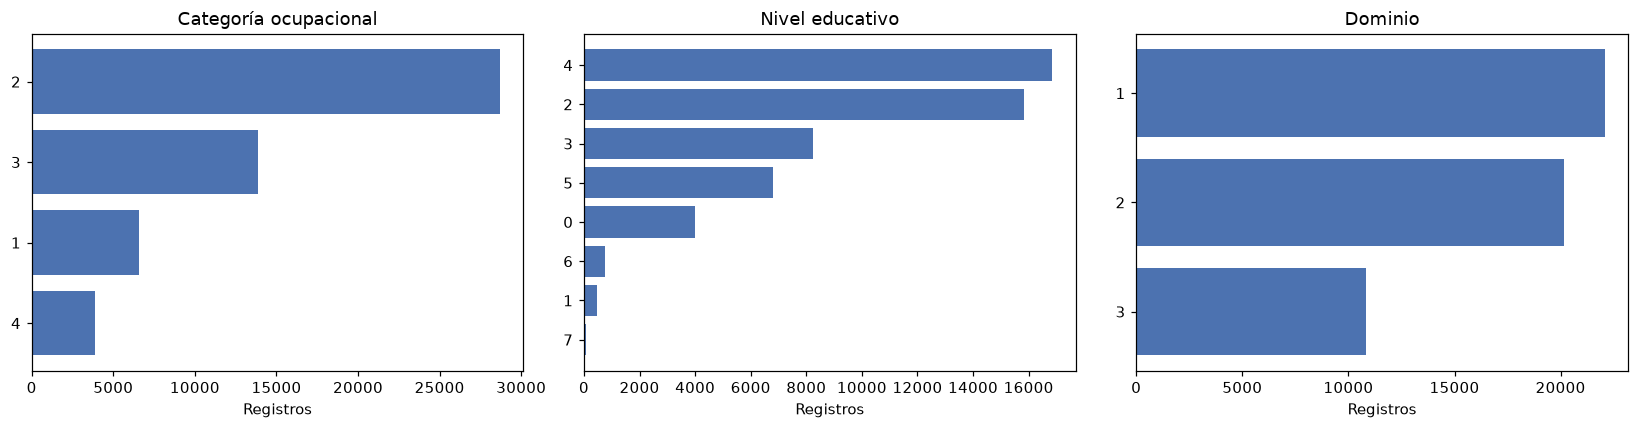

In [16]:
def conteo_categoria(df: DataFrame, columna: str) -> pd.DataFrame:
    return (
        df.groupBy(columna).count()
        .orderBy(F.desc("count"))
        .toPandas()
    )


fig, ejes = plt.subplots(1, 3, figsize=(15, 4))
for eje, columna, titulo in zip(
    ejes,
    ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"],
):
    datos = conteo_categoria(personas_2025_filtrado, columna)
    eje.barh(datos[columna].astype(str), datos["count"], color="#4C72B0")
    eje.invert_yaxis()
    eje.set_title(titulo)
    eje.set_xlabel("Registros")
plt.tight_layout()
plt.show()

### Distribución del salario: ¿simétrica o asimétrica?

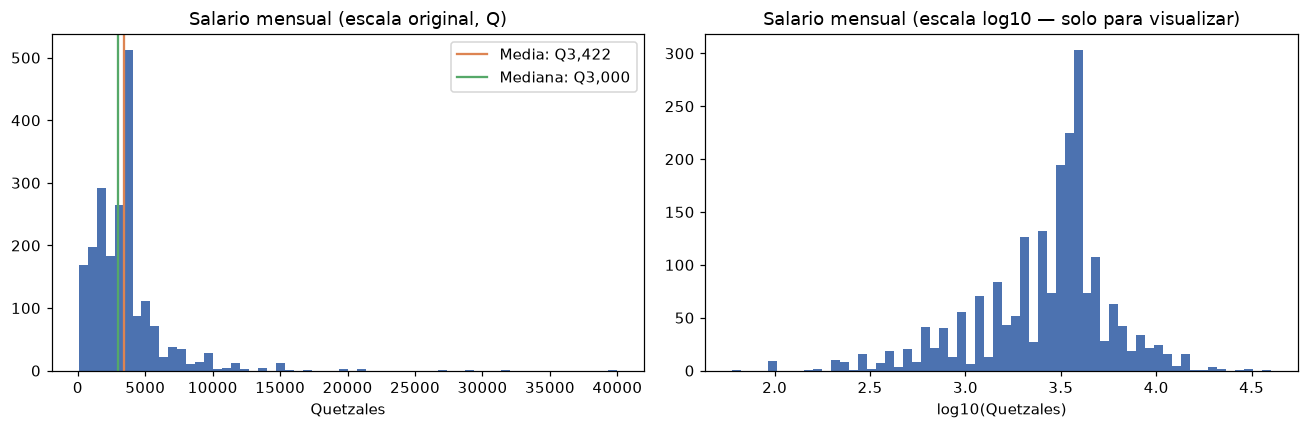

Media: Q3,421.68 | Mediana: Q3,000.00 | Diferencia: Q421.68


In [17]:
muestra_pd = personas_2025_filtrado.select("salario_mensual").sample(
    fraction=min(1.0, N_MUESTRA_GRAFICOS / total_2025), seed=SEMILLA
).toPandas()

media_salario = tabla_resumen.loc[tabla_resumen["variable"] == "salario_mensual", "media"].iloc[0]
mediana_salario = tabla_resumen.loc[tabla_resumen["variable"] == "salario_mensual", "mediana"].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(muestra_pd["salario_mensual"], bins=60, color="#4C72B0")
ax1.axvline(media_salario, color="#DD8452", label=f"Media: Q{media_salario:,.0f}")
ax1.axvline(mediana_salario, color="#55A868", label=f"Mediana: Q{mediana_salario:,.0f}")
ax1.set_title("Salario mensual (escala original, Q)")
ax1.set_xlabel("Quetzales")
ax1.legend()

ax2.hist(np.log10(muestra_pd["salario_mensual"]), bins=60, color="#4C72B0")
ax2.set_title("Salario mensual (escala log10 — solo para visualizar)")
ax2.set_xlabel("log10(Quetzales)")
plt.tight_layout()
plt.show()

print(f"Media: Q{media_salario:,.2f} | Mediana: Q{mediana_salario:,.2f} | Diferencia: Q{media_salario - mediana_salario:,.2f}")

### Salario mediano por nivel educativo y categoría ocupacional

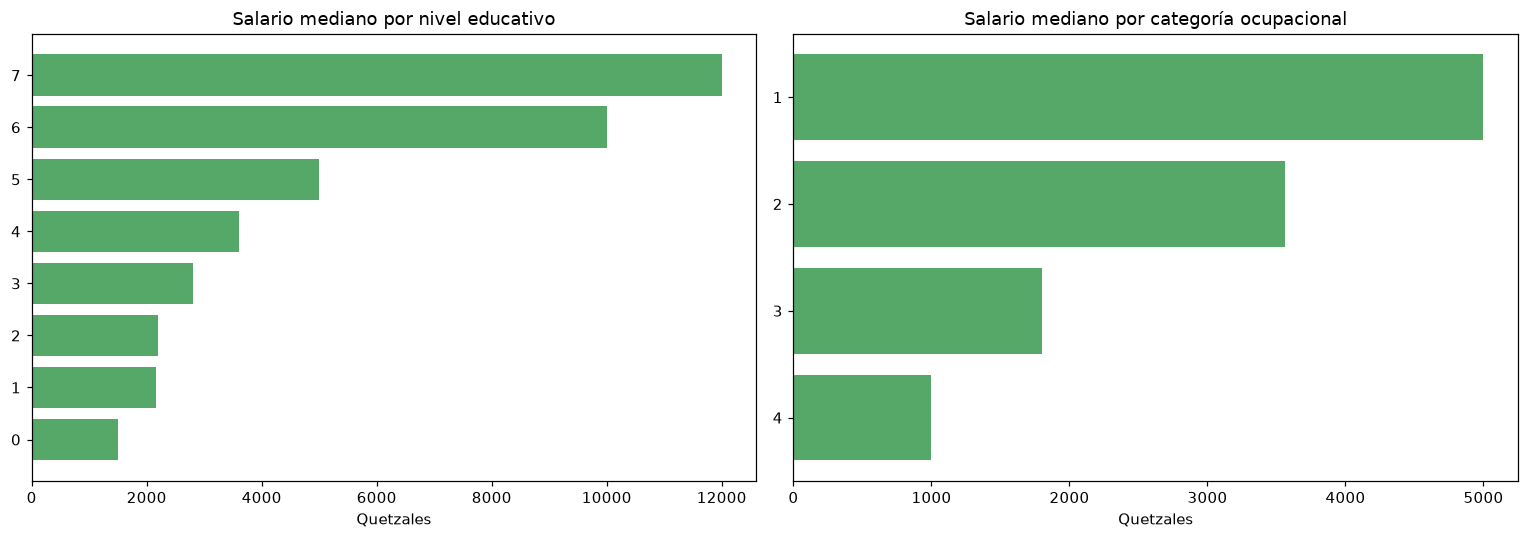

In [18]:
def mediana_por_grupo(df: DataFrame, columna_grupo: str) -> pd.DataFrame:
    return (
        df.groupBy(columna_grupo)
        .agg(
            F.count("*").alias("n"),
            F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
        )
        .orderBy(F.desc("salario_mediano"))
        .toPandas()
    )


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for eje, columna, titulo in zip(
    (ax1, ax2), ("nivel_educativo", "categoria_ocupacional"), ("Nivel educativo", "Categoría ocupacional")
):
    datos = mediana_por_grupo(personas_2025_filtrado, columna)
    eje.barh(datos[columna].astype(str), datos["salario_mediano"], color="#55A868")
    eje.invert_yaxis()
    eje.set_title(f"Salario mediano por {titulo.lower()}")
    eje.set_xlabel("Quetzales")
plt.tight_layout()
plt.show()

### Tamaño de muestra y salario mediano por trimestre

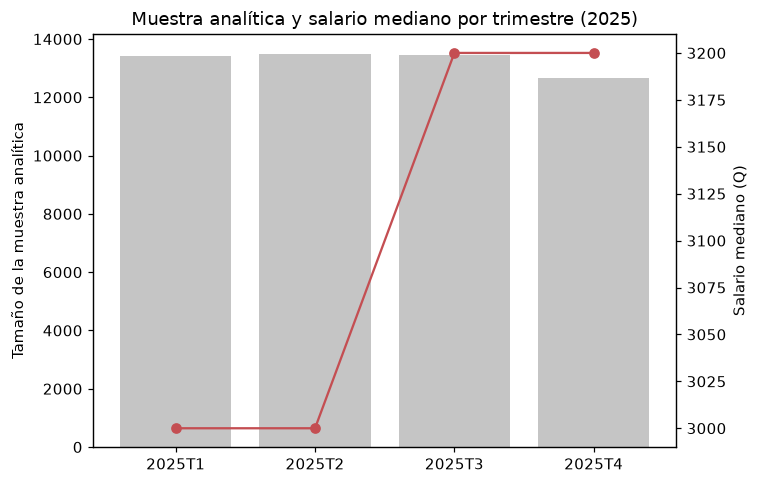

,periodo_archivo,n,salario_mediano
0,2025T1,13419,3000.0
1,2025T2,13492,3000.0
2,2025T3,13450,3200.0
3,2025T4,12664,3200.0


In [19]:
por_trimestre = (
    personas_2025_filtrado.groupBy("periodo_archivo")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
    )
    .orderBy("periodo_archivo")
    .toPandas()
)

fig, ax1 = plt.subplots(figsize=(7, 4.5))
ax2 = ax1.twinx()
ax1.bar(por_trimestre["periodo_archivo"], por_trimestre["n"], color="#8C8C8C", alpha=0.5, label="n")
ax2.plot(por_trimestre["periodo_archivo"], por_trimestre["salario_mediano"], color="#C44E52", marker="o", label="Salario mediano")
ax1.set_ylabel("Tamaño de la muestra analítica")
ax2.set_ylabel("Salario mediano (Q)")
ax1.set_title("Muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout()
plt.show()

por_trimestre

## 3. Relaciones entre variables numéricas (5 pts)

Correlación de Pearson entre salario, edad, antigüedad y horas habituales,
calculada sobre **todos los registros elegibles de 2025** con
`VectorAssembler` + `Correlation.corr` de `pyspark.ml.stat`.

In [20]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

variables_numericas = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

ensamblador = VectorAssembler(inputCols=variables_numericas, outputCol="features_num")
vector_df = ensamblador.transform(
    personas_2025_filtrado.select(*variables_numericas).na.drop()
)

matriz_pearson = Correlation.corr(vector_df, "features_num", "pearson").head()[0].toArray()
correlaciones = pd.DataFrame(matriz_pearson, index=variables_numericas, columns=variables_numericas)
correlaciones.round(3)

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


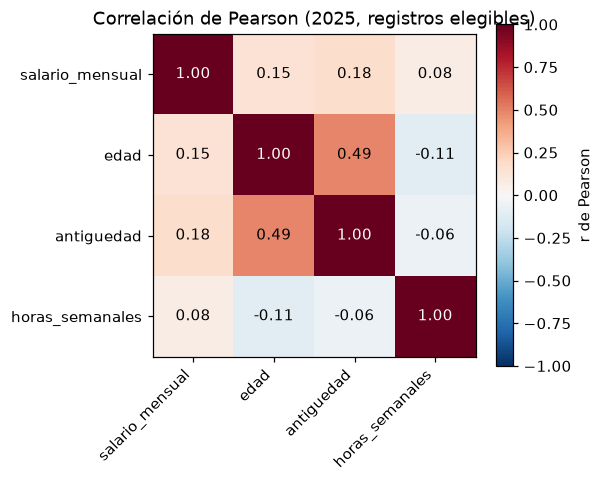

In [21]:
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(correlaciones.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variables_numericas)))
ax.set_yticks(range(len(variables_numericas)))
ax.set_xticklabels(variables_numericas, rotation=45, ha="right")
ax.set_yticklabels(variables_numericas)
for i in range(len(variables_numericas)):
    for j in range(len(variables_numericas)):
        ax.text(j, i, f"{correlaciones.values[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(correlaciones.values[i, j]) > 0.5 else "black")
ax.set_title("Correlación de Pearson (2025, registros elegibles)")
fig.colorbar(im, ax=ax, shrink=0.8, label="r de Pearson")
plt.tight_layout()
plt.show()

**Preguntas — correlaciones**

- **¿Qué variables presentan mayor asociación lineal con el salario?**
  Ninguna de las tres tiene una asociación lineal fuerte con el salario: la
  **antigüedad** (r ≈ 0.18) y la **edad** (r ≈ 0.15) muestran una asociación
  positiva débil, y **horas_semanales** (r ≈ 0.08) es prácticamente nula. Es
  decir, trabajar más horas casi no se traduce linealmente en mayor salario
  en esta muestra; antigüedad y edad pesan un poco más, pero ninguna explica
  el salario por sí sola de forma lineal — es esperable que categoría
  ocupacional, nivel educativo y dominio (variables categóricas, no
  incluidas en esta matriz de Pearson) aporten más en el modelo supervisado.
- **¿Existe relación entre edad y antigüedad?** Sí, es la asociación más
  fuerte de la matriz (r ≈ 0.49, positiva moderada): las personas mayores
  tienden a tener más años de antigüedad en su empleo actual, algo
  razonable ya que han tenido más tiempo para acumularla, aunque la
  relación no es estrecha (r < 0.5) porque la antigüedad también depende de
  cuándo empezó el empleo actual, no solo de la edad de la persona.

## 4. Segmentación de perfiles mediante KMeans (10 pts)

Se segmenta con variables numéricas del perfil laboral: **edad,
antigüedad y horas_semanales**. No se incluye `salario_mensual` como
variable de clustering: es la variable objetivo del modelado supervisado
posterior, e incluirla mezclaría el problema de segmentación (perfiles
laborales) con el de predicción, además de que el salario está mucho más
disperso en escala y dominaría la distancia euclidiana del KMeans incluso
tras estandarizar. En su lugar, el salario se usa **después** para describir
cada clúster (no para formarlo).

In [22]:
from pyspark.ml.feature import StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

variables_cluster = ["edad", "antiguedad", "horas_semanales"]

base_cluster = personas_2025_filtrado.select(
    "periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "salario_mensual",
    "nivel_educativo", "categoria_ocupacional", "dominio", *variables_cluster,
).na.drop(subset=variables_cluster)

ensamblador_cluster = VectorAssembler(inputCols=variables_cluster, outputCol="features_raw")
escalador = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)

vector_cluster = ensamblador_cluster.transform(base_cluster)
modelo_escalador = escalador.fit(vector_cluster)
datos_escalados = modelo_escalador.transform(vector_cluster).cache()

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette", distanceMeasure="squaredEuclidean")

resultados_k = []
modelos_k = {}
for k in [2, 3, 4, 5]:
    kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=SEMILLA)
    modelo = kmeans.fit(datos_escalados)
    predicciones = modelo.transform(datos_escalados)
    silueta = evaluador.evaluate(predicciones)
    resultados_k.append((k, silueta, modelo.summary.trainingCost))
    modelos_k[k] = (modelo, predicciones)

tabla_k = pd.DataFrame(resultados_k, columns=["k", "silhouette", "wssse"])
tabla_k

,k,silhouette,wssse
0,2,0.553203,106718.735299
1,3,0.472130,83608.057407
2,4,0.476448,64438.512290
3,5,0.414617,58304.267650


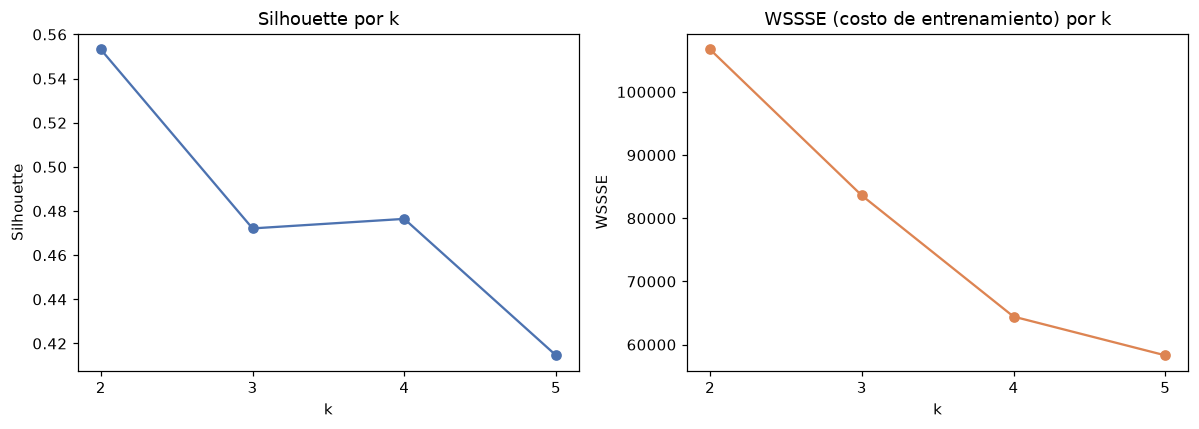

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(tabla_k["k"], tabla_k["silhouette"], marker="o", color="#4C72B0")
ax1.set_title("Silhouette por k")
ax1.set_xlabel("k")
ax1.set_ylabel("Silhouette")
ax1.set_xticks(tabla_k["k"])

ax2.plot(tabla_k["k"], tabla_k["wssse"], marker="o", color="#DD8452")
ax2.set_title("WSSSE (costo de entrenamiento) por k")
ax2.set_xlabel("k")
ax2.set_ylabel("WSSSE")
ax2.set_xticks(tabla_k["k"])
plt.tight_layout()
plt.show()

### Selección de k

**Criterio del equipo:** se elige el `k` con **mayor silhouette** entre
{2,3,4,5} (separación/cohesión de los clústers), usando el WSSSE como
apoyo para descartar un `k` que solo mejore el costo marginalmente (codo).

Con los datos observados, `k=2` tiene el silhouette más alto (≈0.553),
claramente por encima de k=3 (≈0.472), k=4 (≈0.476) y k=5 (≈0.415): la
segmentación se vuelve menos nítida a medida que se agregan más grupos. El
WSSSE sí sigue bajando con más clústers (como es natural, más centroides
siempre reducen el costo), pero sin una caída marcada tipo "codo" que
justifique sacrificar cohesión/separación por más grupos. Por eso el
equipo elige **k = 2**: dos perfiles de trabajadores razonablemente bien
separados en edad, antigüedad y horas semanales.

In [24]:
K_ELEGIDO = int(tabla_k.loc[tabla_k["silhouette"].idxmax(), "k"])
modelo_final, predicciones_final = modelos_k[K_ELEGIDO]
print("k elegido:", K_ELEGIDO)

centros = modelo_escalador.mean if False else None  # los centros del modelo estan en escala estandarizada
for i, centro in enumerate(modelo_final.clusterCenters()):
    print(f"Cluster {i} (features estandarizadas: {variables_cluster}):", np.round(centro, 2))

k elegido: 2
Cluster 0 (features estandarizadas: ['edad', 'antiguedad', 'horas_semanales']): [ 1.19  1.04 -0.27]
Cluster 1 (features estandarizadas: ['edad', 'antiguedad', 'horas_semanales']): [-0.46 -0.4   0.1 ]


### Descripción de cada clúster (variables en su escala original)

In [25]:
descripcion_clusters = (
    predicciones_final.groupBy("cluster")
    .agg(
        F.count("*").alias("n"),
        *[F.mean(v).alias(f"{v}_media") for v in variables_cluster],
        F.expr("percentile_approx(salario_mensual, 0.5)").alias("salario_mediano"),
    )
    .orderBy("cluster")
    .toPandas()
)
descripcion_clusters.round(2)

,cluster,n,edad_media,antiguedad_media,horas_semanales_media,salario_mediano
0,0,14701,51.23,13.74,41.25,3456.0
1,1,38324,29.03,2.42,48.25,3000.0


In [26]:
distribucion_categoria = (
    predicciones_final.groupBy("cluster", "categoria_ocupacional")
    .count()
    .toPandas()
    .pivot(index="cluster", columns="categoria_ocupacional", values="count")
    .fillna(0)
    .astype(int)
)
distribucion_categoria

categoria_ocupacional,1,2,3,4
cluster,,,,
0,3454,6251,3580,1416
1,3121,22451,10262,2490


**Interpretación de los clústers** (k = 2)

- **Clúster 0 — "senior / alta antigüedad" (n ≈ 14,701; ~27.7% de la
  muestra analítica).** Edad media ≈ 51 años, antigüedad media ≈ 13.7 años,
  jornada media ≈ 41.3 h/semana (cercana a tiempo completo estándar) y
  salario mediano más alto (Q3,456). Es un perfil de trabajadores
  establecidos, con muchos años en su puesto actual. Proporcionalmente
  concentra más empleados de gobierno (23.5% de este clúster, contra 8.1%
  en el otro) y menos empresa privada (42.5% contra 58.6%).
- **Clúster 1 — "joven / poca antigüedad" (n ≈ 38,324; ~72.3% de la
  muestra analítica).** Edad media ≈ 29 años, antigüedad media ≈ 2.4 años,
  jornada media ≈ 48.3 h/semana (más larga que el clúster 0, pese a menor
  antigüedad) y salario mediano más bajo (Q3,000). Es el perfil
  predominante de la fuerza laboral asalariada analizada: mayoritariamente
  empleados de empresa privada (58.6%).

En conjunto, la segmentación separa sobre todo por **antigüedad/edad**
(diferencia de ~11 años en antigüedad), no tanto por horas trabajadas
(ambos clústers rondan tiempo completo), y el clúster de mayor antigüedad
tiene un salario mediano ~15% más alto.

## Siguientes pasos (entrega final, domingo 27 de septiembre)

Esta sección deja preparados y guardados en Parquet los conjuntos de 2025
(`data/processed/eneic_2025_preparado.parquet`) y de 2026T1
(`data/processed/eneic_2026t1_preparado.parquet`) para continuar con:

5. Pipeline de Regresión Lineal.
6. Pipeline de Random Forest.
7. Entrenamiento final y evaluación en 2026.
8. Visualización y análisis de errores.